In [1]:
import pandas as pd

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Q1. Downloading the data

We'll use the same NYC taxi dataset, but instead of "Green Taxi Trip Records", we'll use "Yellow Taxi Trip Records".

Download the data for January and February 2023.

In [2]:
jan_df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet')
feb_df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet')

In [3]:
len(jan_df.columns)

19

### Q2. Computing duration

In [4]:
df = jan_df

In [5]:
df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df['duration'] = df.duration.dt.total_seconds() / 60

In [6]:
df.duration.mean()

np.float64(15.668995167330452)

In [7]:
df.duration.std()

np.float64(42.59435124195458)

### Q3. Dropping outliers

In [8]:
len(df[(df.duration >= 1) & (df.duration <= 60)]) / len(df) * 100

98.1220282212598

In [9]:
df = df[(df.duration >= 1) & (df.duration <= 60)].copy()

### Q4. One-hot encoding

In [11]:
categorical = ['PULocationID', 'DOLocationID']
df[categorical] = df[categorical].astype(str)

train_dicts = df[categorical].to_dict(orient='records')

In [12]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [13]:
print(f'Feature matrix size: {X_train.shape}')

Feature matrix size: (3009173, 515)


### Question 5. Training a model. RMSE on train 

In [14]:
target = 'duration'
y_train = df[target].values

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)



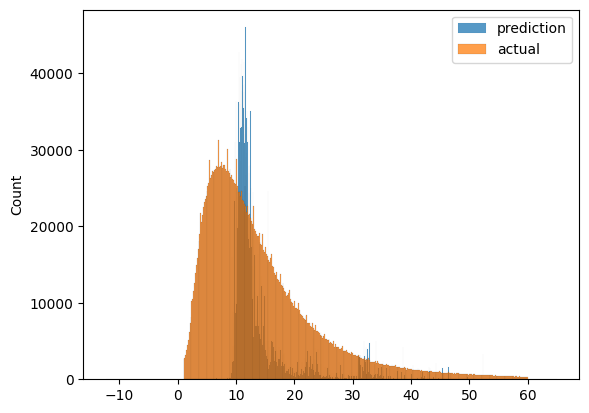

In [17]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_train, label='actual')

plt.legend();

In [23]:
# print(f'Train RMSE: {mean_squared_error(y_train, y_pred)}')
import numpy as np
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
rmse

np.float64(7.649261936284003)

### Q6. Evaluating the model

In [24]:
categorical = ['PULocationID', 'DOLocationID']

def read_data(filename):
    df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)].copy()

    df[categorical] = df[categorical].astype('str')
    
    return df

In [29]:
df_val = read_data('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet')

val_dicts = df_val[categorical].to_dict(orient='records')

In [31]:
X_val = dv.transform(val_dicts) 
y_val = df_val.duration.values

y_pred = lr.predict(X_val)

In [34]:
# print(f'Val RMSE: {mean_squared_error(y_val, y_pred, squared=False)}')
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
rmse

np.float64(7.811818654341152)